# Day 4 & 5: Data Exploration

In this notebook, we will load the AG News dataset and perform some initial exploration to understand its structure, content, class distribution, and text characteristics.

In [1]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print("Train dataset loaded.")
train_df.head()

Train dataset loaded.


,text,label
0,AMD #39;s new dual-core Opteron chip is design...,3
1,Reuters - Major League Baseball\Monday announc...,1
2,President Bush #39;s quot;revenue-neutral quo...,2
3,Britain will run out of leading scientists unl...,3
4,"London, England (Sports Network) - England mid...",1


In [2]:
print("Test dataset loaded.")
test_df.head()

Test dataset loaded.


,text,label
0,"CHARLOTTE, N.C. (Sports Network) - Carolina P...",1
1,"PRESENTACION, Philippines (Reuters) - Philipp...",0
2,"SAN FRANCISCO, CA - November 30, 2004 -Ubisoft...",3
3,DANIEL VETTORI spun New Zealand to the brink o...,1
4,AFP - Georgian and South Ossetian forces overn...,0


In [3]:
# Get information about the training data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [4]:
# Check for missing values
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
text     0
label    0
dtype: int64

Missing values in test data:
text     0
label    0
dtype: int64


In [5]:
# Look at the class distribution
print("Class distribution in training data:")
print(train_df['label'].value_counts())

Class distribution in training data:
label
3    30000
1    30000
2    30000
0    30000
Name: count, dtype: int64


# Data Exploration and Preprocessing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training data
df = pd.read_csv('../data/train.csv')

# Display the first few rows
print(df.head())

# Display info
print(df.info())

                                                text  label
0  AMD #39;s new dual-core Opteron chip is design...      3
1  Reuters - Major League Baseball\Monday announc...      1
2  President Bush #39;s  quot;revenue-neutral quo...      2
3  Britain will run out of leading scientists unl...      3
4  London, England (Sports Network) - England mid...      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB
None


In [7]:
# Check for missing values
print(df.isnull().sum())

text     0
label    0
dtype: int64


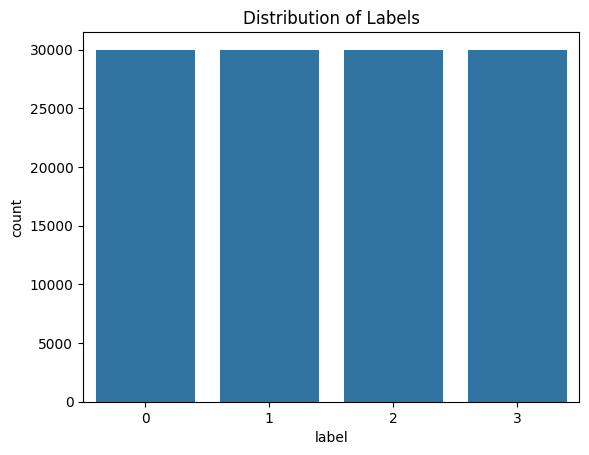

In [8]:
# Show distribution of labels
sns.countplot(x='label', data=df)
plt.title('Distribution of Labels')
plt.show()

## Analyze Text Characteristics 
Now, let's analyze the text lengths and word counts to understand the dataset better.

In [9]:
# Calculate text length
df['text_length'] = df['text'].apply(len)

# Calculate word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print(df[['text_length', 'word_count']].describe())

         text_length     word_count
count  120000.000000  120000.000000
mean      193.402017      31.062692
std        64.452006       9.757035
min        20.000000       3.000000
25%       155.000000      25.000000
50%       188.000000      30.000000
75%       219.000000      36.000000
max       985.000000     173.000000


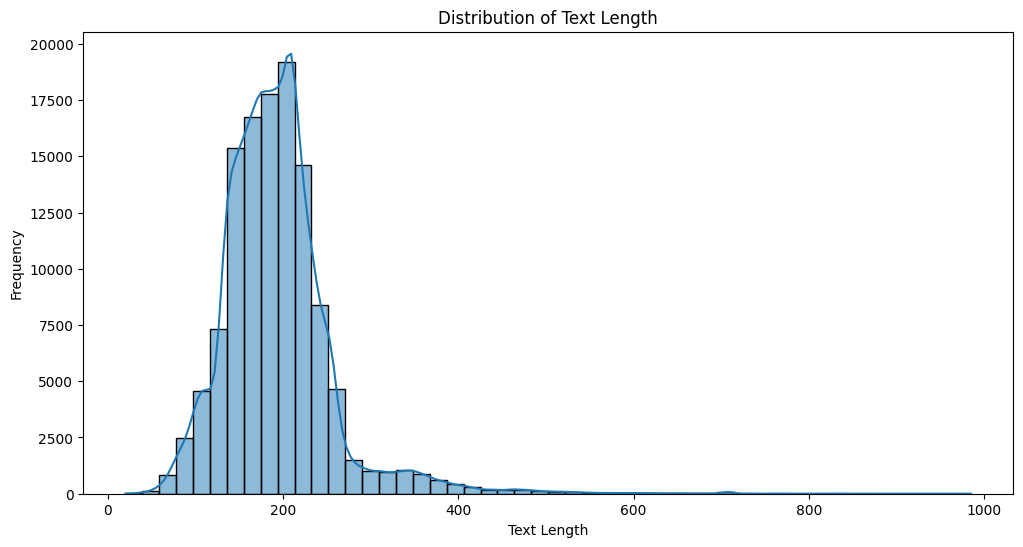

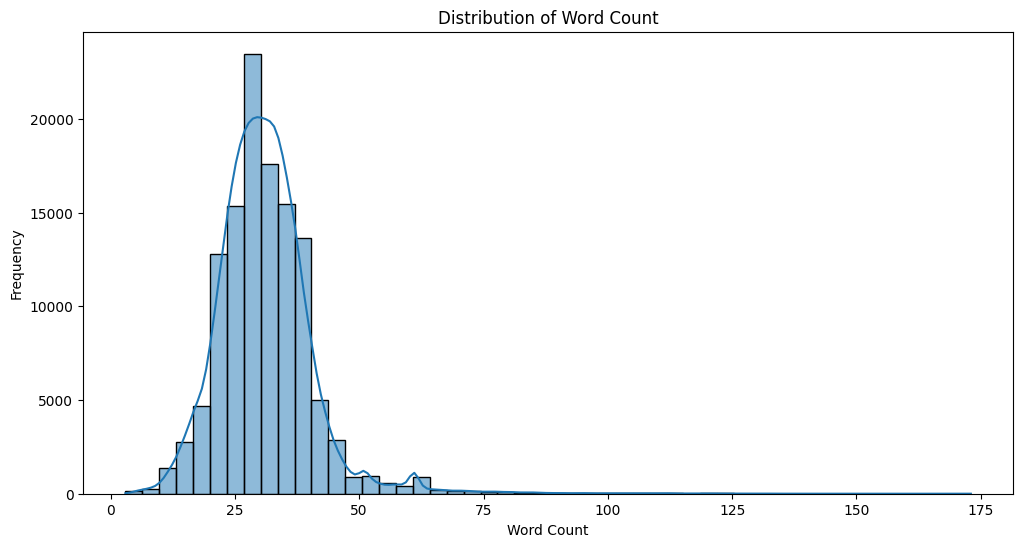

In [10]:
# Plot distribution of text length
plt.figure(figsize=(12, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

# Plot distribution of word count
plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


# Advanced Preprocessing using Custom Module
Now, we'll use our modular preprocessing pipeline from `src/preprocessing.py` to process the text. This is a best practice as it separates logic from the notebook, making the code cleaner and reusable.


In [ ]:

# Save the processed data to a new file
processed_output_path = '../data/train_processed.csv'
df.to_csv(processed_output_path, index=False)

print(f"Processed data saved to {processed_output_path}")



## Save the Processed Data
Finally, we save the DataFrame with the fully processed text to a new CSV file. This file will be the input for our modeling phase.


In [ ]:

import sys
import os

# Add the src directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from preprocessing import preprocess_pipeline

# Apply the advanced preprocessing pipeline
# This might take a moment as it involves lemmatization
df['processed_text'] = df['text'].apply(preprocess_pipeline)

print("Advanced preprocessing complete.")
print(df[['text', 'processed_text']].head())


In [ ]:

import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    """
    Removes stopwords from a list of tokens.
    """
    return [word for word in tokens if word not in stop_words]

# Apply the stopword removal
df['tokenized_text'] = df['tokenized_text'].apply(remove_stopwords)
print(df[['tokenized_text']].head())


In [ ]:

# Save the cleaned data to a new file
output_path = '../data/train_cleaned.csv'
df.to_csv(output_path, index=False, columns=['label', 'cleaned_text', 'tokenized_text'])

print(f"Cleaned data saved to {output_path}")
